In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage


In [ ]:
# ── Load & Preprocess ──
df = pd.read_csv("Mall_Customers.csv")
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Load & Preprocess ──
df = pd.read_csv("Mall_Customers.csv")
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

FEATURES = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = StandardScaler().fit_transform(df[FEATURES])

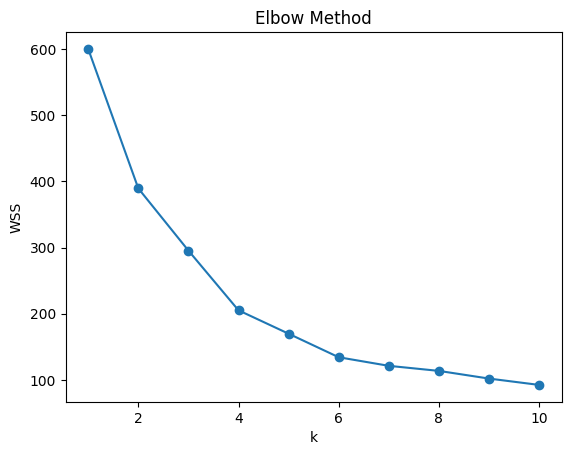

In [ ]:
# ── Elbow Method ──
wss = [KMeans(n_clusters=k, random_state=42).fit(X).inertia_ for k in range(1, 11)]
plt.plot(range(1, 11), wss, 'o-')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('WSS')
plt.show()

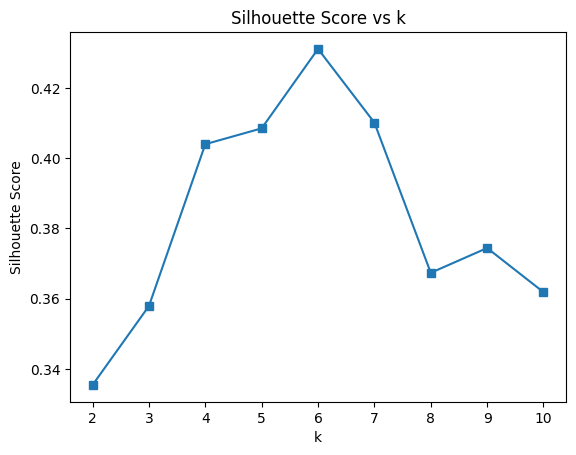

In [ ]:
sil = [silhouette_score(X, KMeans(n_clusters=k, random_state=42).fit_predict(X)) for k in range(2, 11)]
plt.plot(range(2, 11), sil, 's-')
plt.title('Silhouette Score vs k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.show()


In [ ]:
# ── KMeans ──
k = 5
km = KMeans(n_clusters=k, random_state=42)
df['kmeans_cluster'] = km.fit_predict(X)
print("KMeans Silhouette:", silhouette_score(X, df['kmeans_cluster']))
print("KMeans Davies-Bouldin:", davies_bouldin_score(X, df['kmeans_cluster']))

KMeans Silhouette: 0.40846873777345605
KMeans Davies-Bouldin: 0.8889693268899006


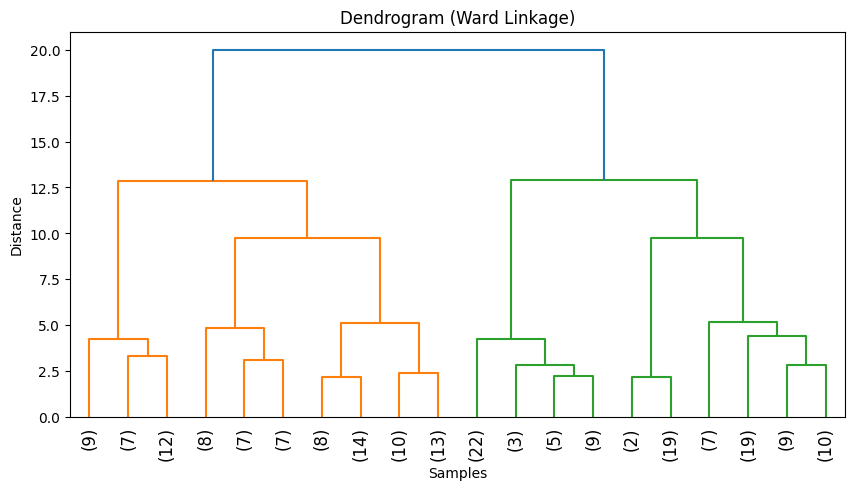

Hierarchical Silhouette: 0.39002826186267214


In [ ]:

# ── Hierarchical + Dendrogram ──
Z = linkage(X, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X)
print("Hierarchical Silhouette:", silhouette_score(X, df['hc_cluster']))

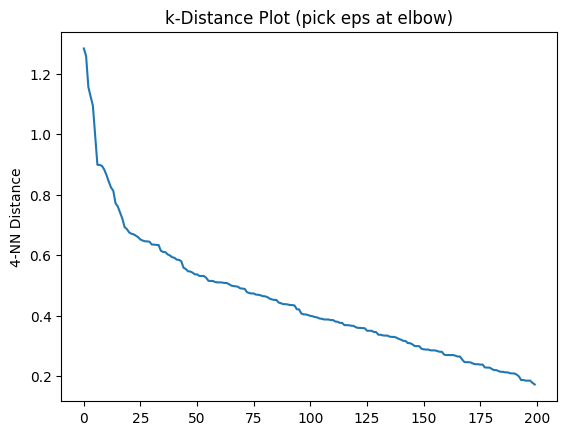

DBSCAN Clusters: 6, Noise points: 60


In [ ]:
# ── DBSCAN ──
# k-distance plot to pick eps
nbrs = NearestNeighbors(n_neighbors=4).fit(X)
distances, _ = nbrs.kneighbors(X)
plt.plot(np.sort(distances[:, 3])[::-1])
plt.title('k-Distance Plot (pick eps at elbow)')
plt.ylabel('4-NN Distance')
plt.show()

db = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_cluster'] = db.fit_predict(X)
n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
print(f"DBSCAN Clusters: {n_clusters}, Noise points: {(df['dbscan_cluster'] == -1).sum()}")

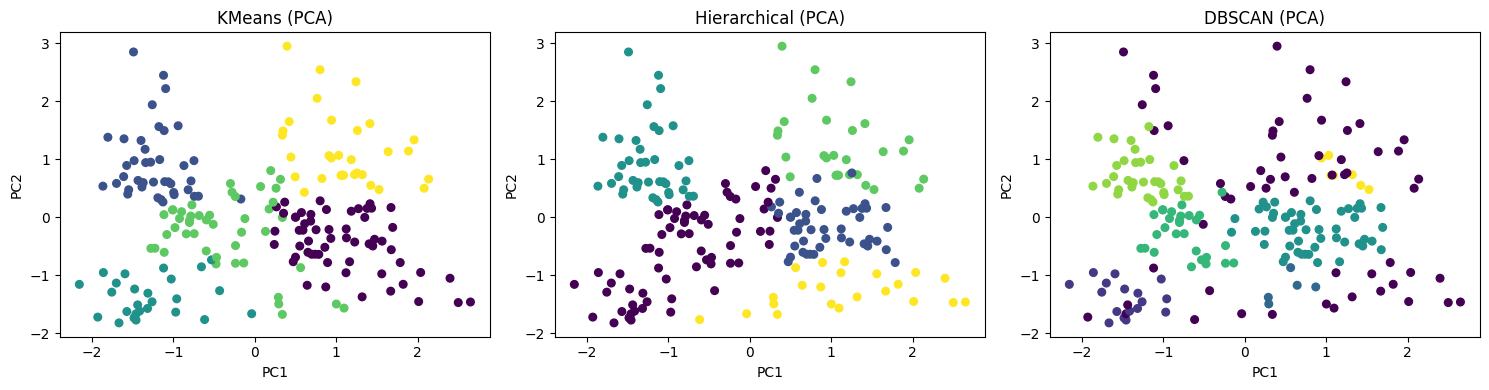

In [ ]:
# ── PCA Visualization ──
X_pca = PCA(n_components=2).fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                           ['kmeans_cluster', 'hc_cluster', 'dbscan_cluster'],
                           ['KMeans', 'Hierarchical', 'DBSCAN']):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df[col], cmap='viridis', s=30)
    ax.set_title(f'{title} (PCA)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

In [ ]:
# ── Cluster Profiles ──
print("\nKMeans Cluster Profiles:")
print(df.groupby('kmeans_cluster')[FEATURES].mean().round(2))


KMeans Cluster Profiles:
                  Age  Annual Income (k$)  Spending Score (1-100)
kmeans_cluster                                                   
0               55.28               47.62                   41.71
1               32.88               86.10                   81.53
2               25.77               26.12                   74.85
3               26.73               54.31                   40.91
4               44.39               89.77                   18.48


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000       

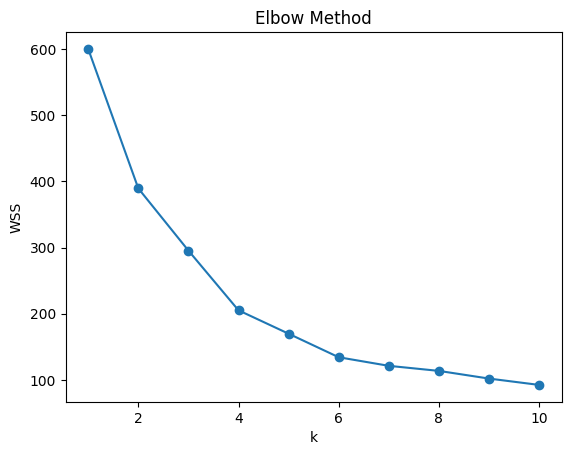

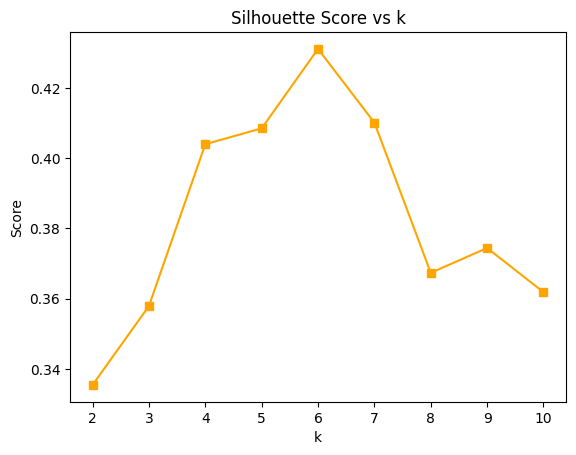

KMeans Silhouette     : 0.4085
KMeans Davies-Bouldin : 0.889


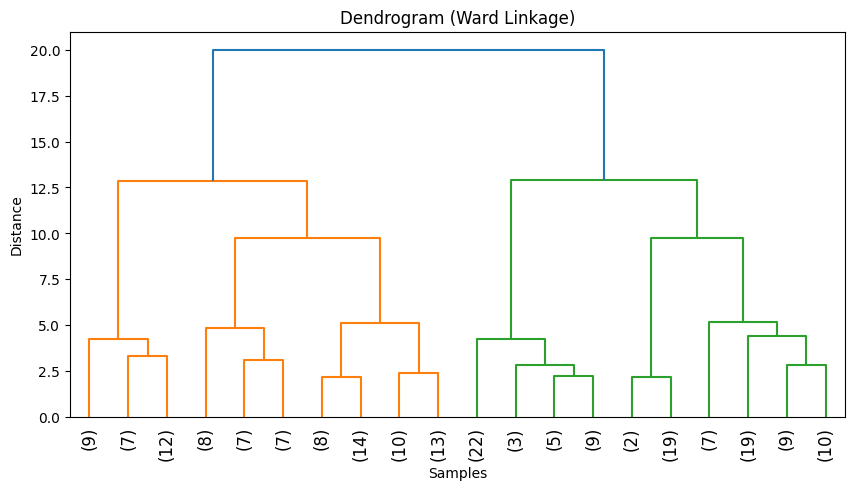

Hierarchical Silhouette     : 0.39
Hierarchical Davies-Bouldin : 0.9163


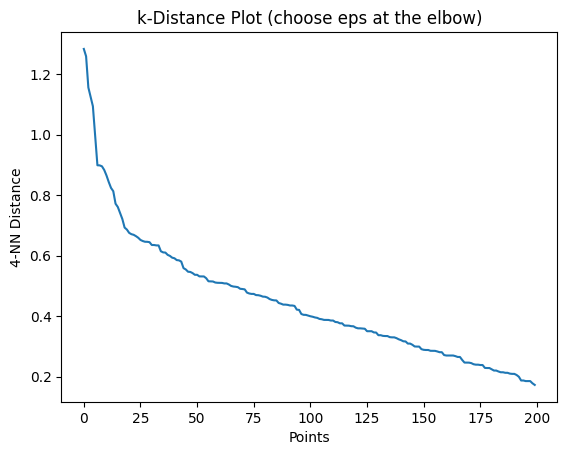

DBSCAN → Clusters: 6, Noise points: 60


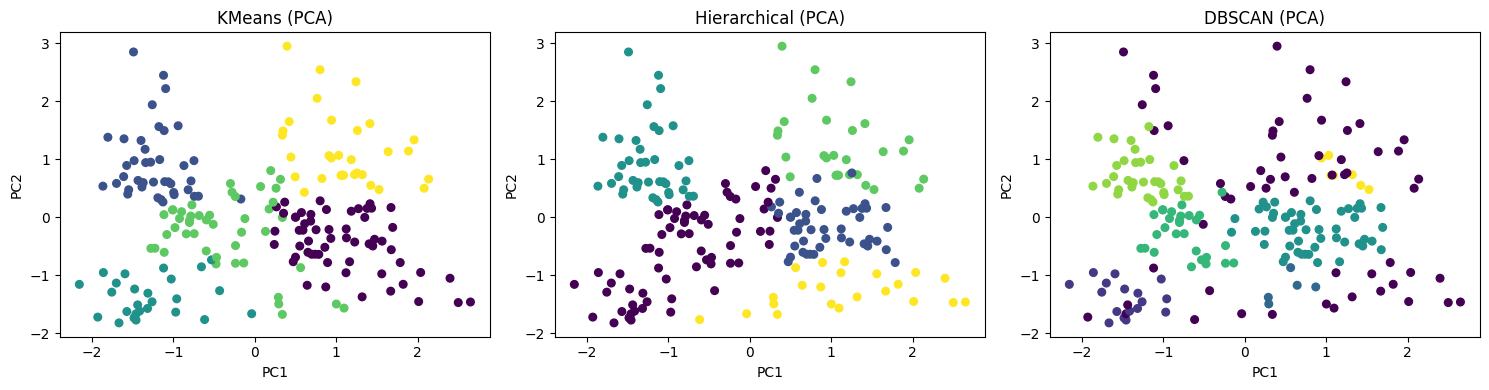


KMeans Cluster Profiles:
                  Age  Annual Income (k$)  Spending Score (1-100)
kmeans_cluster                                                   
0               55.28               47.62                   41.71
1               32.88               86.10                   81.53
2               25.77               26.12                   74.85
3               26.73               54.31                   40.91
4               44.39               89.77                   18.48


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Load & Preprocess ──
df = pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.describe())
print("Missing values:\n", df.isnull().sum())

df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

FEATURES = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = StandardScaler().fit_transform(df[FEATURES])

# ── Elbow Method ──
wss = [KMeans(n_clusters=k, random_state=42).fit(X).inertia_ for k in range(1, 11)]
plt.plot(range(1, 11), wss, 'o-')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('WSS')
plt.show()

# ── Silhouette Score vs k ──
sil = [silhouette_score(X, KMeans(n_clusters=k, random_state=42).fit_predict(X)) for k in range(2, 11)]
plt.plot(range(2, 11), sil, 's-', color='orange')
plt.title('Silhouette Score vs k')
plt.xlabel('k')
plt.ylabel('Score')
plt.show()

# ── KMeans ──
k = 5
km = KMeans(n_clusters=k, random_state=42)
df['kmeans_cluster'] = km.fit_predict(X)
print("KMeans Silhouette     :", round(silhouette_score(X, df['kmeans_cluster']), 4))
print("KMeans Davies-Bouldin :", round(davies_bouldin_score(X, df['kmeans_cluster']), 4))

# ── Hierarchical Clustering + Dendrogram ──
Z = linkage(X, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X)
print("Hierarchical Silhouette     :", round(silhouette_score(X, df['hc_cluster']), 4))
print("Hierarchical Davies-Bouldin :", round(davies_bouldin_score(X, df['hc_cluster']), 4))

# ── DBSCAN — k-distance plot to choose eps ──
nbrs = NearestNeighbors(n_neighbors=4).fit(X)
distances, _ = nbrs.kneighbors(X)
plt.plot(np.sort(distances[:, 3])[::-1])
plt.title('k-Distance Plot (choose eps at the elbow)')
plt.ylabel('4-NN Distance')
plt.xlabel('Points')
plt.show()

db = DBSCAN(eps=0.5, min_samples=5)   # adjust eps from plot above
df['dbscan_cluster'] = db.fit_predict(X)
n_clust = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
print(f"DBSCAN → Clusters: {n_clust}, Noise points: {(df['dbscan_cluster'] == -1).sum()}")

# ── PCA Visualization (all 3 algorithms) ──
X_pca = PCA(n_components=2).fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                           ['kmeans_cluster', 'hc_cluster', 'dbscan_cluster'],
                           ['KMeans', 'Hierarchical', 'DBSCAN']):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df[col], cmap='viridis', s=30)
    ax.set_title(f'{title} (PCA)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

# ── Cluster Profiles ──
print("\nKMeans Cluster Profiles:")
print(df.groupby('kmeans_cluster')[FEATURES].mean().round(2))